# Part 1
## Fitness Classification Dataset

```text
Dataset: Real-World Style Fitness Classification Dataset (Synthetic)
URL:     https://www.kaggle.com/datasets/muhammedderric/fitness-classification-dataset-synthetic/data
Task:    binary classification 
Target:  is_fit  (1 = fit, 0 = not fit)
```


1. EDA
2. Розбиття та препроцесинг
3. Інженерія та відбір ознак
4. PCA / t-SNE візуалізація (власні реалізації)


In [28]:
# Imports & global setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, time, warnings

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import mutual_info_classif

# Own implementations from labs
from pca_svd_student import PCA as MyPCA
from dim_viz_student import TSNE as MyTSNE

warnings.filterwarnings('ignore')
np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

---
## Частина 1. Завантаження та розвідувальний аналіз (EDA)


### 1.1 Завантаження та огляд

In [29]:
df = pd.read_csv('fitness_dataset.csv')
print('Shape:', df.shape)
df.head()

Shape: (2000, 11)


,age,height_cm,weight_kg,heart_rate,blood_pressure,sleep_hours,nutrition_quality,activity_index,smokes,gender,is_fit
0,56,152,65,69.6,117.0,NaN,2.37,3.97,no,F,1
1,69,186,95,60.8,114.8,7.5,8.77,3.19,0,F,1
2,46,192,103,61.4,116.4,NaN,8.20,2.03,0,F,0
3,32,189,83,60.2,130.1,7.0,6.18,3.68,0,M,1
4,60,175,99,58.1,115.8,8.0,9.95,4.83,yes,F,1


In [30]:
print('Dtypes:')
print(df.dtypes)
print('\nDescribe:')
df.describe(include='all').T

Dtypes:
age                    int64
height_cm              int64
weight_kg              int64
heart_rate           float64
blood_pressure       float64
sleep_hours          float64
nutrition_quality    float64
activity_index       float64
smokes                object
gender                object
is_fit                 int64
dtype: object

Describe:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,2000.0,NaN,NaN,NaN,49.114,17.926564,18.0,34.0,49.0,65.0,79.0
height_cm,2000.0,NaN,NaN,NaN,174.533,14.37175,150.0,162.0,174.0,187.0,199.0
weight_kg,2000.0,NaN,NaN,NaN,83.5405,25.852534,30.0,64.0,83.0,102.0,250.0
heart_rate,2000.0,NaN,NaN,NaN,70.2886,11.846339,45.0,62.1,70.25,78.425,118.6
blood_pressure,2000.0,NaN,NaN,NaN,119.90885,14.578032,90.0,109.7,120.0,129.8,171.2
sleep_hours,1840.0,NaN,NaN,NaN,7.513315,1.502031,4.0,6.5,7.5,8.6,12.0
nutrition_quality,2000.0,NaN,NaN,NaN,5.03514,2.864156,0.0,2.5475,5.065,7.47,10.0
activity_index,2000.0,NaN,NaN,NaN,2.99904,1.136383,1.0,2.0375,2.98,3.95,4.99
smokes,2000,4,yes,711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,2000,2,F,1030,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# Унікальні значення проблемних стовпців
print("smokes unique:", df['smokes'].unique())
print("gender unique:", df['gender'].unique())

smokes unique: ['no' '0' 'yes' '1']
gender unique: ['F' 'M']


- 11 стовпців, 1 цільова (`is_fit`), 9 предикторів + 1 (gender) тип `object`.
- `smokes` має змішані типи (`0`, `1`, `'yes'`, `'no'`) — потребує нормалізації.
- `sleep_hours` має пропуски.
- `weight_kg` із потенційними викидами.


In [32]:
# Базова чистка: уніфікуємо 'smokes'
def normalize_smokes(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in {'1', 'yes', 'y', 'true'}:
        return 1
    if s in {'0', 'no', 'n', 'false'}:
        return 0
    return np.nan

df['smokes'] = df['smokes'].map(normalize_smokes)
print('After normalisation:', df['smokes'].unique())

After normalisation: [0 1]


In [33]:
TARGET = 'is_fit'
NUM_COLS = ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure',
            'sleep_hours', 'nutrition_quality', 'activity_index', 'smokes']
CAT_COLS = ['gender']
print('Numerical:', len(NUM_COLS), '— ', NUM_COLS)
print('Categorical:', len(CAT_COLS), '— ', CAT_COLS)

Numerical: 9 —  ['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours', 'nutrition_quality', 'activity_index', 'smokes']
Categorical: 1 —  ['gender']


> `smokes` після нормалізації трактуємо як числову бінарну ознаку. `gender` — єдина категоріальна.

### 1.2 Цільова змінна

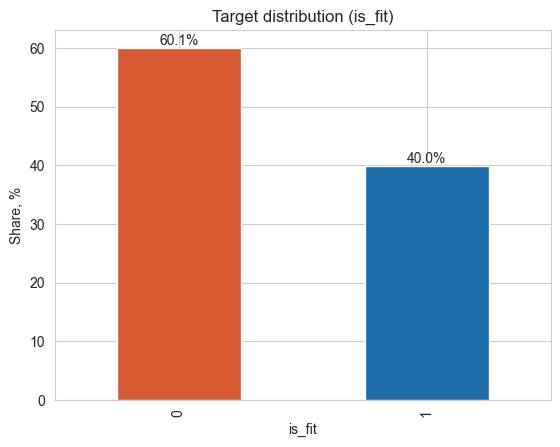

is_fit
0    1201
1     799
Name: count, dtype: int64


In [34]:
ax = (df[TARGET].value_counts(normalize=True).sort_index() * 100).plot(
    kind='bar', color=['#d65a31', '#1b6ca8'])
ax.set_title('Target distribution (is_fit)')
ax.set_xlabel('is_fit')
ax.set_ylabel('Share, %')
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom')
plt.show()
print(df[TARGET].value_counts())

**Висновок:** дисбаланс присутній (~60 / 40). Не критичний, але `accuracy` буде завищувати якість для тривіальних класифікаторів. Використовуватимемо також **F1**, **Precision/Recall** і **ROC-AUC**, які чутливіші до меншого класу.

### 1.3 Числові ознаки

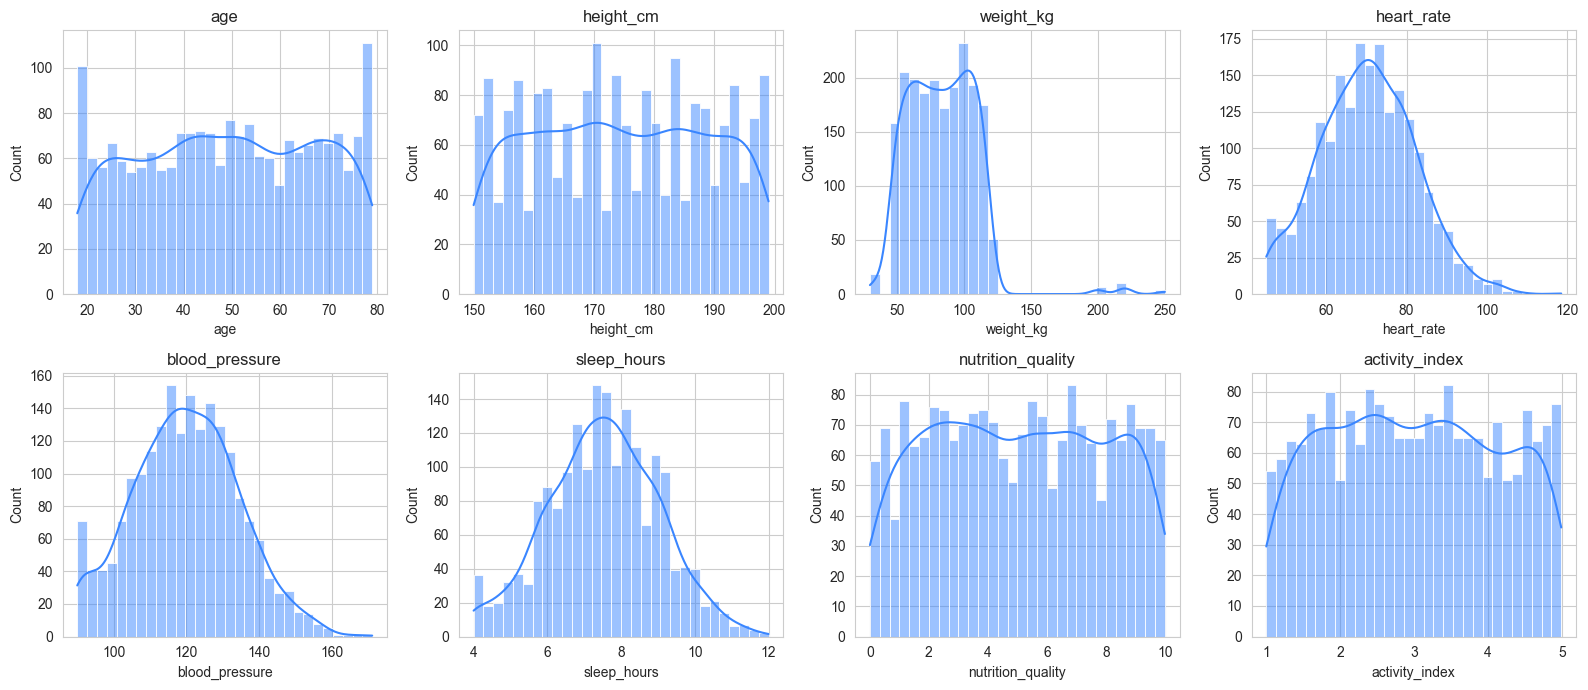

In [35]:
num_for_hist = [c for c in NUM_COLS if c != 'smokes']  # smokes — бінарна
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.ravel(), num_for_hist):
    sns.histplot(df[col].dropna(), bins=30, kde=True, ax=ax, color='#3a86ff')
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [36]:
# IQR-аналіз викидів
def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lo) | (s > hi)).sum()
    return n_out, lo, hi

print(f"{'col':<20s} {'n_out':>6s} {'low':>10s} {'high':>10s}")
for col in num_for_hist:
    n_out, lo, hi = iqr_outliers(df[col].dropna())
    print(f"{col:<20s} {n_out:>6d} {lo:>10.2f} {hi:>10.2f}")

col                   n_out        low       high
age                       0     -12.50     111.50
height_cm                 0     124.50     224.50
weight_kg                21       7.00     159.00
heart_rate               10      37.61     102.91
blood_pressure            4      79.55     159.95
sleep_hours               2       3.35      11.75
nutrition_quality         0      -4.84      14.85
activity_index            0      -0.83       6.82


 `weight_kg` показує найвиразніші викиди. Інші числові ознаки мають помірні хвости, без аномалій. 

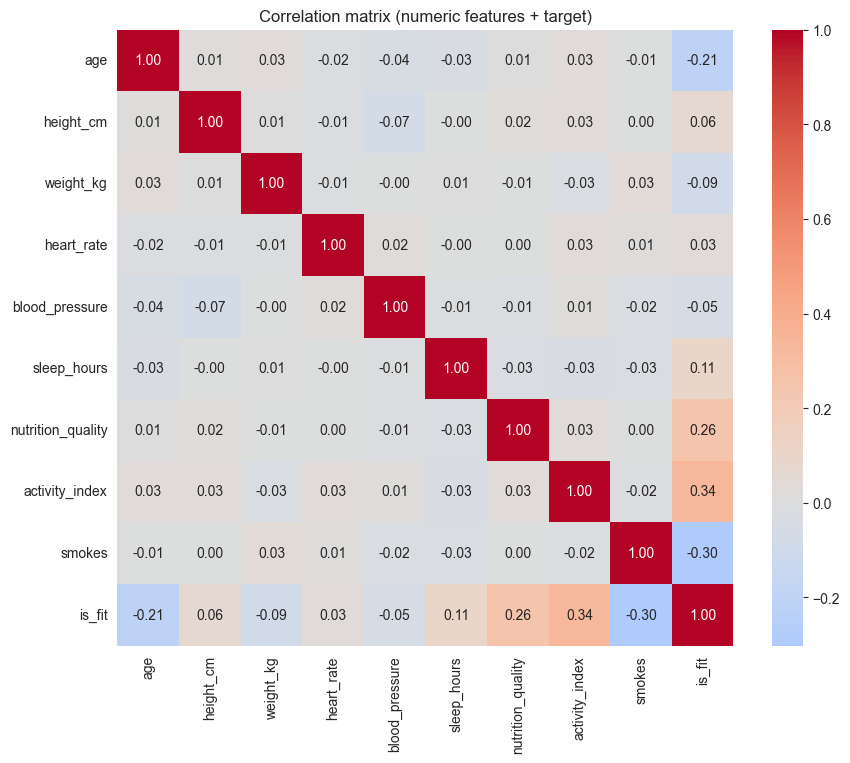

Top correlations with target:
activity_index       0.343187
smokes               0.301503
nutrition_quality    0.255423
age                  0.214002
sleep_hours          0.109074
weight_kg            0.088033
height_cm            0.064877
blood_pressure       0.051010
heart_rate           0.032763
Name: is_fit, dtype: float64


In [37]:
# Кореляційна матриця (числові + ціль)
plt.figure(figsize=(10, 8))
corr = df[NUM_COLS + [TARGET]].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix (numeric features + target)')
plt.show()

print('Top correlations with target:')
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False))

**Висновок:** найсильніше пов'язані з ціллю - `nutrition_quality`, `activity_index`, `smokes`, `age`. 

### 1.4 Категоріальні ознаки

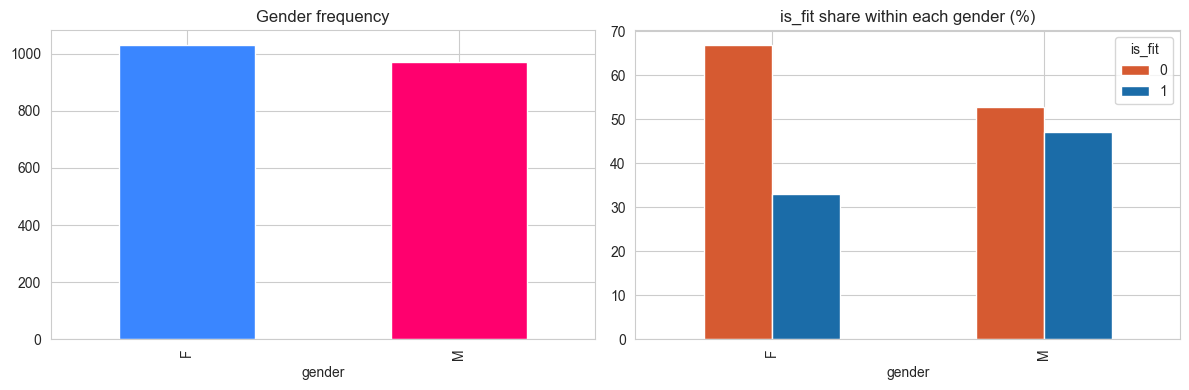

In [38]:
# Частоти gender + grouped bar з ціллю
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['gender'].value_counts().plot(kind='bar', ax=axes[0], color=['#3a86ff', '#ff006e'])
axes[0].set_title('Gender frequency')

ct = pd.crosstab(df['gender'], df[TARGET], normalize='index') * 100
ct.plot(kind='bar', ax=axes[1], color=['#d65a31', '#1b6ca8'])
axes[1].set_title('is_fit share within each gender (%)')
axes[1].legend(title='is_fit')
plt.tight_layout()
plt.show()

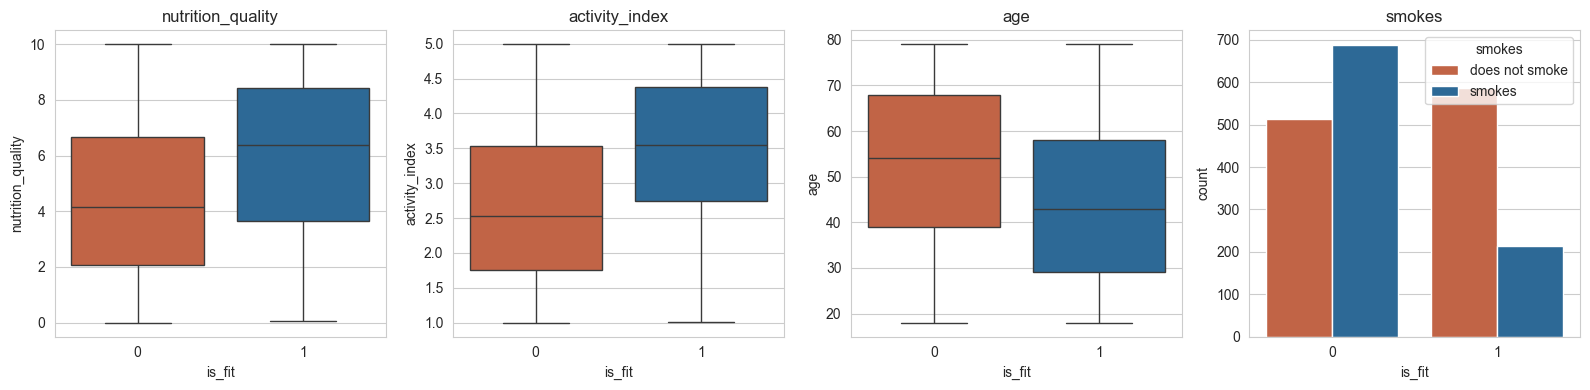

In [39]:
# 3-4 найважливіші числові: boxplot vs target
top_num = ['nutrition_quality', 'activity_index', 'age']
binary_col = 'smokes'

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# числові ознаки — boxplot
for ax, col in zip(axes[:3], top_num):
    sns.boxplot(
        x='is_fit',
        y=col,
        data=df,
        ax=ax,
        palette=['#d65a31', '#1b6ca8']
    )
    ax.set_title(col)

# smokes — countplot
sns.countplot(
    x='is_fit',
    hue='smokes',
    data=df,
    ax=axes[3],
    palette=['#d65a31', '#1b6ca8']
)

axes[3].set_title('smokes')
axes[3].set_xlabel('is_fit')
axes[3].set_ylabel('count')
axes[3].legend(title='smokes', labels=['does not smoke', 'smokes'])

plt.tight_layout()
plt.show()

**Спостереження:** `is_fit=1` має вищу `nutrition_quality`, вищий `activity_index`, нижчий `heart_rate`, частіше `smokes=0`. Узгоджено з кореляційною матрицею.

### 1.5 Пропущені значення

In [40]:
# Явні NaN
miss_pct = (df.isna().mean() * 100).round(2)
print('Missing %:')
print(miss_pct[miss_pct > 0])

# Приховані замінники в числових — після нормалізації smokes їх немає,
# але перевіримо повторно
hidden_tokens = ['unknown', 'N/A', 'na', '-1', '999']
hits = {}
for col in df.select_dtypes(include='object').columns:
    s = df[col].astype(str).str.lower()
    n = s.isin(hidden_tokens).sum()
    if n:
        hits[col] = n
print('Hidden missing tokens:', hits if hits else 'none')

Missing %:
sleep_hours    8.0
dtype: float64
Hidden missing tokens: none


**Стратегія обробки:**
- `sleep_hours` (~8% NaN) - числова, пропуски випадкові: **median imputation** у пайплайні. Медіана стійкіша до асиметрії, ніж середнє.
- `gender` - пропусків немає, але pipeline захищаємо через `most_frequent` impute про всяк випадок.

Імпутацію виконуємо **тільки на train** (через `Pipeline`) - без витоку даних.

---
## Частина 2. Розбиття даних та попередня обробка


### 2.1 Розбиття 70 / 15 / 15 зі стратифікацією

In [41]:
X = df.drop(columns=[TARGET]).copy()
y = df[TARGET].astype(int).copy()

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.15/0.85,
    random_state=RANDOM_STATE, stratify=y_trainval)

print('Sizes  : train={}, val={}, test={}'.format(len(X_train), len(X_val), len(X_test)))
print('Targets:')
for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    print(f'  {name:<5s} class1 share = {yy.mean():.3f}')

Sizes  : train=1400, val=300, test=300
Targets:
  train class1 share = 0.399
  val   class1 share = 0.400
  test  class1 share = 0.400


Розподіл цільової у всіх трьох наборах — близько 40% позитивного класу. Стратифікація працює.

### 2.2 Препроцесинг-пайплайн

In [42]:
class PercentileClipper(BaseEstimator, TransformerMixin):
    """Clip features at given lower/upper percentiles fitted on train."""
    def __init__(self, lower=1, upper=99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.lo_ = np.nanpercentile(X, self.lower, axis=0)
        self.hi_ = np.nanpercentile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        return np.clip(X, self.lo_, self.hi_)


numeric_pipeline = Pipeline(steps=[
    ('clipper', PercentileClipper(lower=1, upper=99)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, NUM_COLS),
    ('cat', categorical_pipeline, CAT_COLS),
])
preprocessor; 

In [43]:
# Fit on TRAIN only, transform all three
preprocessor.fit(X_train, y_train)

X_train_p = preprocessor.transform(X_train)
X_val_p   = preprocessor.transform(X_val)
X_test_p  = preprocessor.transform(X_test)

# Build feature names
ohe = preprocessor.named_transformers_['cat'].named_steps['ohe']
cat_feature_names = list(ohe.get_feature_names_out(CAT_COLS))
FEATURE_NAMES = NUM_COLS + cat_feature_names

print('Features after pipeline:', X_train_p.shape[1])
print(FEATURE_NAMES)

Features after pipeline: 11
['age', 'height_cm', 'weight_kg', 'heart_rate', 'blood_pressure', 'sleep_hours', 'nutrition_quality', 'activity_index', 'smokes', 'gender_F', 'gender_M']


**Висновок:** 11 ознак на виході (9 числових + 2 OHE-стовпці для `gender`).

---
## Частина 3. Інженерія та відбір ознак


### 3.1 Нові ознаки


| Ознака | Формула | Сенс |
|--------|---------|------|
| `bmi` | `weight_kg / (height_cm/100) ** 2` | Класичний індекс маси тіла. |
| `health_score` | `nutrition_quality * activity_index * (1 - smokes)` | Композиція здорових факторів. |
| `sleep_dev` | `(sleep_hours - 7).abs()` | Відхилення від рекомендованих 7 годин (в обидва боки). |


In [44]:
def add_engineered(df_in):
    df_out = df_in.copy()
    df_out['bmi'] = df_out['weight_kg'] / (df_out['height_cm'] / 100.0) ** 2
    smokes_filled = df_out['smokes'].fillna(df_out['smokes'].median())
    sleep_filled  = df_out['sleep_hours'].fillna(df_out['sleep_hours'].median())
    df_out['health_score'] = (
        df_out['nutrition_quality'] * df_out['activity_index'] * (1 - smokes_filled))
    df_out['sleep_dev'] = (sleep_filled - 7.0).abs()
    return df_out

X_train_fe = add_engineered(X_train)
X_val_fe   = add_engineered(X_val)
X_test_fe  = add_engineered(X_test)
NEW_FEATS  = ['bmi', 'health_score', 'sleep_dev']

# Попередня оцінка значущості: кореляція з ціллю на train
print('Pearson |corr| with target on train:')
for col in NEW_FEATS:
    c = np.corrcoef(X_train_fe[col].fillna(X_train_fe[col].median()),
                    y_train)[0, 1]
    print(f'  {col:<18s} {c:+.3f}')

Pearson |corr| with target on train:
  bmi                -0.135
  health_score       +0.450
  sleep_dev          +0.091


In [45]:
# Розширений препроцесор з новими числовими ознаками
NUM_COLS_FE = NUM_COLS + NEW_FEATS

numeric_pipeline_fe = Pipeline(steps=[
    ('clipper', PercentileClipper(lower=1, upper=99)),
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
preprocessor_fe = ColumnTransformer(transformers=[
    ('num', numeric_pipeline_fe, NUM_COLS_FE),
    ('cat', categorical_pipeline, CAT_COLS),
])
preprocessor_fe.fit(X_train_fe, y_train)

X_train_pf = preprocessor_fe.transform(X_train_fe)
X_val_pf   = preprocessor_fe.transform(X_val_fe)
X_test_pf  = preprocessor_fe.transform(X_test_fe)

ohe2 = preprocessor_fe.named_transformers_['cat'].named_steps['ohe']
FEATURE_NAMES_FE = NUM_COLS_FE + list(ohe2.get_feature_names_out(CAT_COLS))
print('Features after FE pipeline:', X_train_pf.shape[1])

Features after FE pipeline: 14


### 3.2 Відбір ознак — mutual information

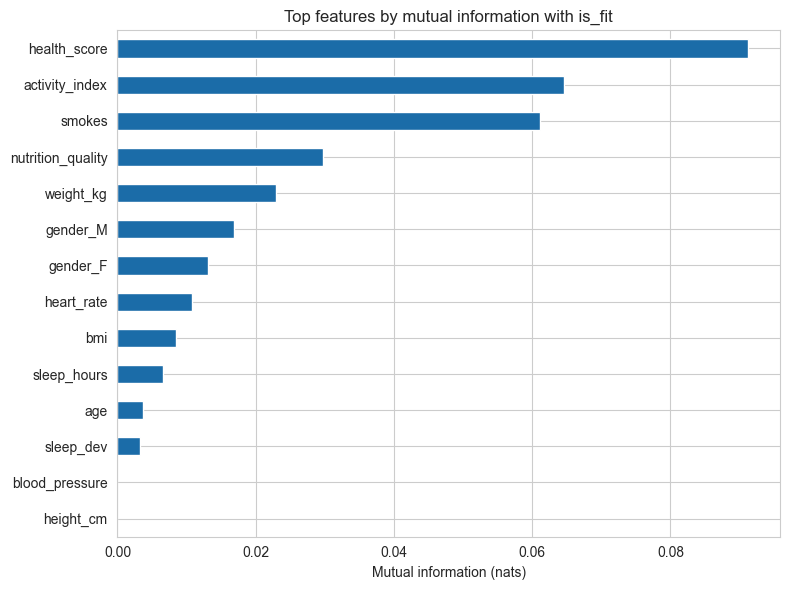

health_score         0.091
activity_index       0.065
smokes               0.061
nutrition_quality    0.030
weight_kg            0.023
gender_M             0.017
gender_F             0.013
heart_rate           0.011
bmi                  0.009
sleep_hours          0.007
age                  0.004
sleep_dev            0.003
height_cm            0.000
blood_pressure       0.000
dtype: float64


In [46]:
mi = mutual_info_classif(X_train_pf, y_train, random_state=RANDOM_STATE)
mi_series = pd.Series(mi, index=FEATURE_NAMES_FE).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
mi_series.tail(20).plot(kind='barh', color='#1b6ca8')
plt.title('Top features by mutual information with is_fit')
plt.xlabel('Mutual information (nats)')
plt.tight_layout()
plt.show()
print(mi_series.sort_values(ascending=False).round(3))

**Висновок:** домінує **інженерна ознака** `health_score`, разом із базовими `nutrition_quality`, `activity_index`, `smokes`. `age`, `sleep_dev` мають низьку MI - це сигнал про слабку безпосередню залежність, але вони можуть допомагати через нелінійні взаємодії.

Залишаємо всі ознаки - їх лише 13, і відкидати корисні нелінійні ефекти на цьому етапі ризиковано.

---
## Частина 4. Візуалізація у зниженому просторі (PCA та t-SNE)


In [47]:
# Підвибірка max 3000 (у нас train ~1400, тож беремо весь train)
rng = np.random.default_rng(RANDOM_STATE)
n_sub = min(3000, X_train_pf.shape[0])
sub_idx = rng.choice(X_train_pf.shape[0], n_sub, replace=False)
X_sub = X_train_pf[sub_idx]
y_sub = y_train.values[sub_idx]
print('PCA/t-SNE subsample size:', n_sub)

PCA/t-SNE subsample size: 1400


### 4.1 PCA — з лабораторної

Components for 90% variance: 9


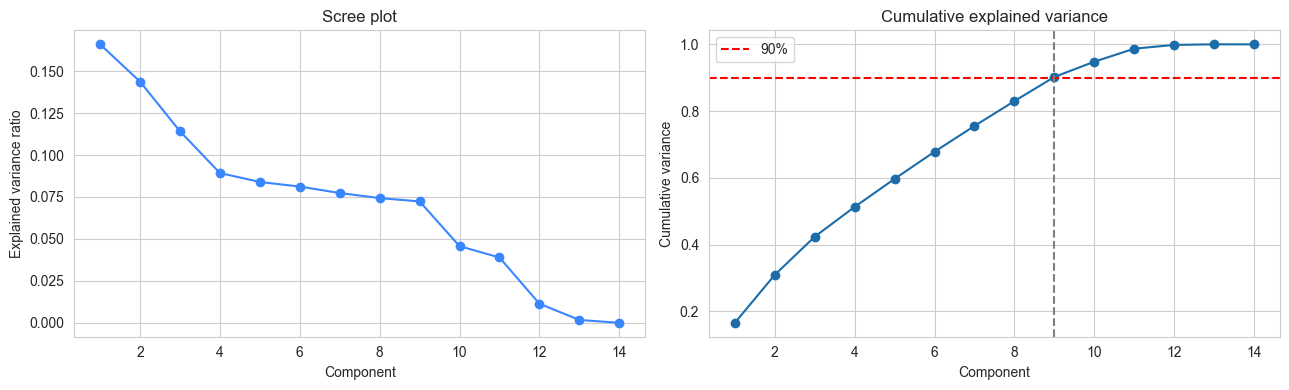

In [48]:
pca_full = MyPCA(n_components=None).fit(X_sub)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)

n90 = int(np.searchsorted(cum, 0.90) + 1)
print(f'Components for 90% variance: {n90}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(np.arange(1, len(evr)+1), evr, 'o-', color='#3a86ff')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained variance ratio')
axes[0].set_title('Scree plot')

axes[1].plot(np.arange(1, len(cum)+1), cum, 'o-', color='#1b6ca8')
axes[1].axhline(0.9, ls='--', color='red', label='90%')
axes[1].axvline(n90, ls='--', color='gray')
axes[1].set_xlabel('Component'); axes[1].set_ylabel('Cumulative variance')
axes[1].set_title('Cumulative explained variance')
axes[1].legend()
plt.tight_layout(); plt.show()

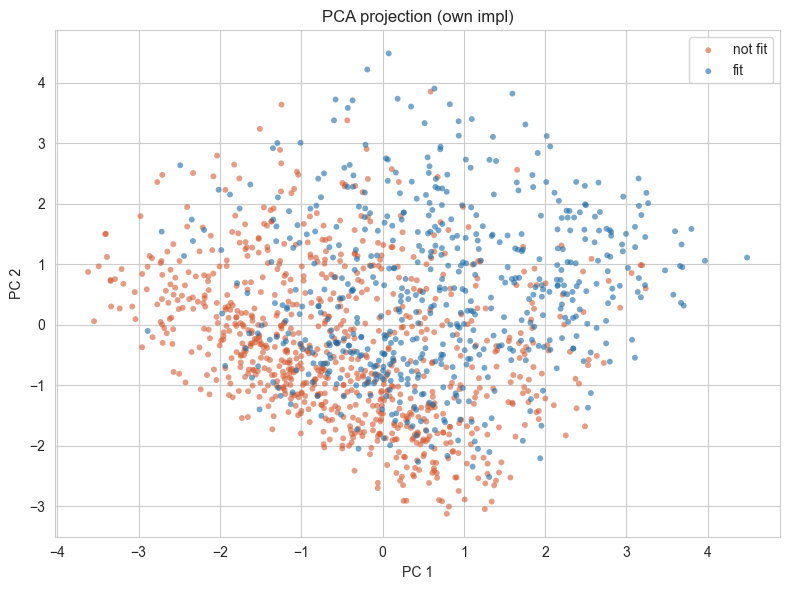

In [49]:
pca2 = MyPCA(n_components=2).fit(X_sub)
Z_pca = pca2.transform(X_sub)

plt.figure(figsize=(8, 6))
for cls, color, label in [(0, '#d65a31', 'not fit'), (1, '#1b6ca8', 'fit')]:
    mask = y_sub == cls
    plt.scatter(Z_pca[mask, 0], Z_pca[mask, 1], c=color, alpha=0.6,
                edgecolors='none', label=label, s=18)
plt.xlabel('PC 1'); plt.ylabel('PC 2'); plt.title('PCA projection (own impl)')
plt.legend(); plt.tight_layout(); plt.show()

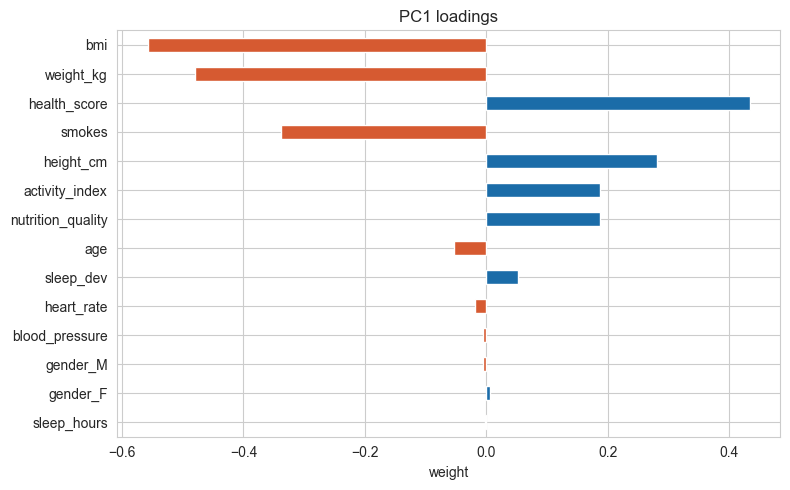

In [50]:
# Loadings of PC1
loadings_pc1 = pd.Series(pca2.components_[0], index=FEATURE_NAMES_FE)
loadings_pc1.reindex(loadings_pc1.abs().sort_values(ascending=False).index)
plt.figure(figsize=(8, 5))
loadings_pc1.reindex(loadings_pc1.abs().sort_values().index).plot(
    kind='barh', color=np.where(loadings_pc1.reindex(loadings_pc1.abs().sort_values().index) >= 0,
                                '#1b6ca8', '#d65a31'))
plt.title('PC1 loadings'); plt.xlabel('weight'); plt.tight_layout(); plt.show()

 PC1 - здебільшого вісь «здоров'я» (поєднує `health_score`, `nutrition_quality`, `activity_index` зі знаком плюс і `bmi`, `weight`, `smokes` зі знаком мінус). 

### 4.2 t-SNE — з лабораторної

In [51]:
X_train_pf.shape[0]

1400

In [52]:
n_tsne = X_train_pf.shape[0]

X_tsne_in = X_train_pf
y_tsne_in = y_train.values

embeddings = {}

for perp in [15, 30, 50]:
    print(f'Running t-SNE perplexity={perp} on {n_tsne} samples...')
    
    tsne = MyTSNE(
        n_components=2,
        perplexity=perp,
        n_iter=400,
        learning_rate=200.0,
        momentum=0.8,
        random_state=RANDOM_STATE
    )
    
    embeddings[perp] = tsne.fit_transform(X_tsne_in)
    
    print(f'  final KL = {tsne.kl_curve_[-1]:.4f}')

Running t-SNE perplexity=15 on 1400 samples...
  final KL = 1.8859
Running t-SNE perplexity=30 on 1400 samples...
  final KL = 1.7406
Running t-SNE perplexity=50 on 1400 samples...
  final KL = 1.5838


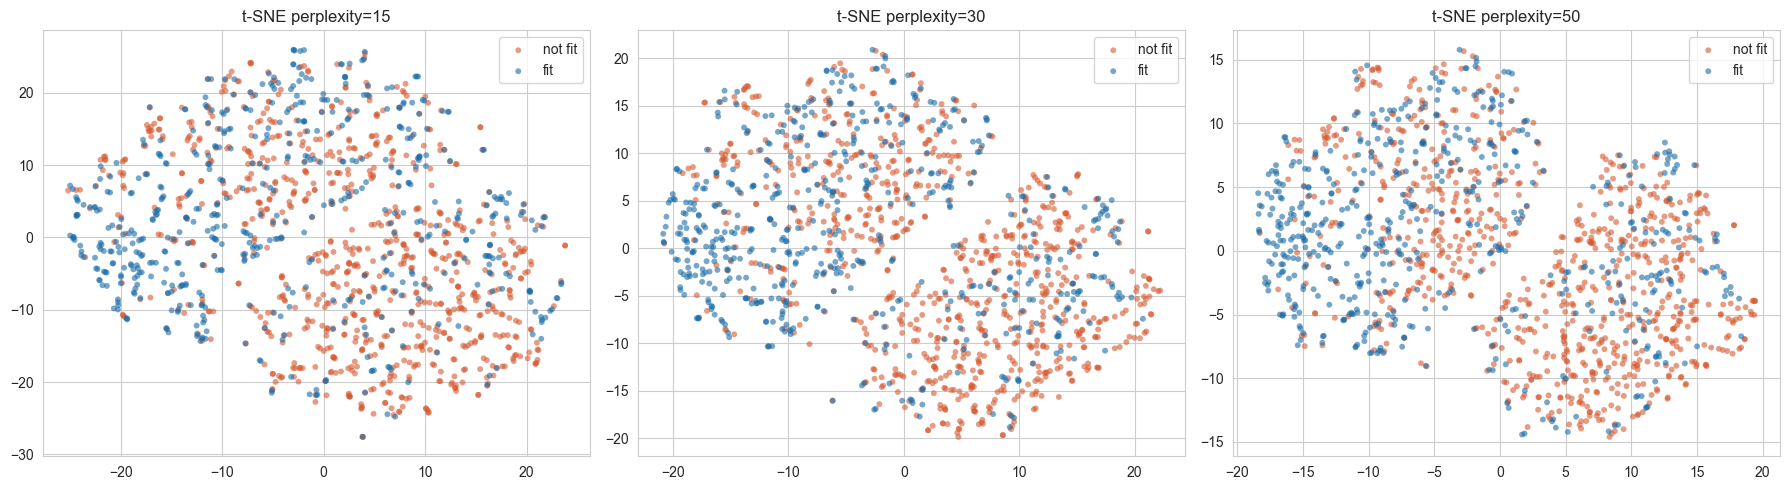

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (perp, Y) in zip(axes, embeddings.items()):
    for cls, color, label in [(0, '#d65a31', 'not fit'), (1, '#1b6ca8', 'fit')]:
        mask = y_tsne_in == cls
        ax.scatter(Y[mask, 0], Y[mask, 1], c=color, alpha=0.6,
                   edgecolors='none', label=label, s=18)
    ax.set_title(f't-SNE perplexity={perp}')
    ax.legend()
plt.tight_layout(); plt.show()

На графіках видно, що класи `fit` і `not fit` не утворюють повністю відокремлених кластерів, а значною мірою перетинаються. Водночас спостерігаються локальні області з переважанням одного класу: частина `fit`-об’єктів концентрується зліва, тоді як значна частина `not fit`-об’єктів розташована правіше/нижче. Це означає, що в ознаках є корисна структура для класифікації, але межа між класами не є простою та ідеально роздільною.

---
## Збереження артефактів для Part 2

Зберігаємо препроцесовані матриці та цільові, щоб не повторювати кроки в наступному ноутбуці.


In [54]:
import os, pickle
os.makedirs('artifacts', exist_ok=True)
with open('artifacts/part1_data.pkl', 'wb') as f:
    pickle.dump({
        'X_train': X_train_pf, 'X_val': X_val_pf, 'X_test': X_test_pf,
        'y_train': y_train.values, 'y_val': y_val.values, 'y_test': y_test.values,
        'feature_names': FEATURE_NAMES_FE,
        'num_cols_fe': NUM_COLS_FE, 'cat_cols': CAT_COLS,
    }, f)
print('Saved to artifacts/part1_data.pkl')

Saved to artifacts/part1_data.pkl
